In [1]:
import pickle

exports_folder_path = "/private/schwartz-lab/yarin_shaked7/SkyRL/data/exports/"
sub_experiment_name = "Qwen3-4B_spartan_reward_coef_10.0_format_reward_coef_0.5_accuracy_reward_coef_1.0_context_4000_lr_1.0e-5/"
file_path = "eval_summary_table.pkl"
r_spartan_i_spartan_path = exports_folder_path + "L40_rewards_SPARTAN_instructions_SPARTAN_model_Qwen/" + sub_experiment_name + file_path
r_spartan_i_vanilla_path = exports_folder_path + "RTX6000_rewards_SPARTAN_instructions_VANILLA_model_Qwen/" + sub_experiment_name + file_path
r_vanilla_i_spartan_path = exports_folder_path + "RTX6000_rewards_VANILLA_instructions_SPARTAN_model_Qwen/" + sub_experiment_name + file_path
r_vanilla_i_vanilla_path = exports_folder_path + "RTX6000_rewards_VANILLA_instructions_VANILLA_model_Qwen/" + sub_experiment_name + file_path

with open(r_spartan_i_spartan_path, "rb") as f:
    r_spartan_i_spartan_data = pickle.load(f)
    r_spartan_i_spartan_data = r_spartan_i_spartan_data.get_dataframe()

with open(r_spartan_i_vanilla_path, "rb") as f:
    r_spartan_i_vanilla_data = pickle.load(f)
    r_spartan_i_vanilla_data = r_spartan_i_vanilla_data.get_dataframe()

with open(r_vanilla_i_spartan_path, "rb") as f:
    r_vanilla_i_spartan_data = pickle.load(f)
    r_vanilla_i_spartan_data = r_vanilla_i_spartan_data.get_dataframe()

with open(r_vanilla_i_vanilla_path, "rb") as f:
    r_vanilla_i_vanilla_data = pickle.load(f)
    r_vanilla_i_vanilla_data = r_vanilla_i_vanilla_data.get_dataframe()

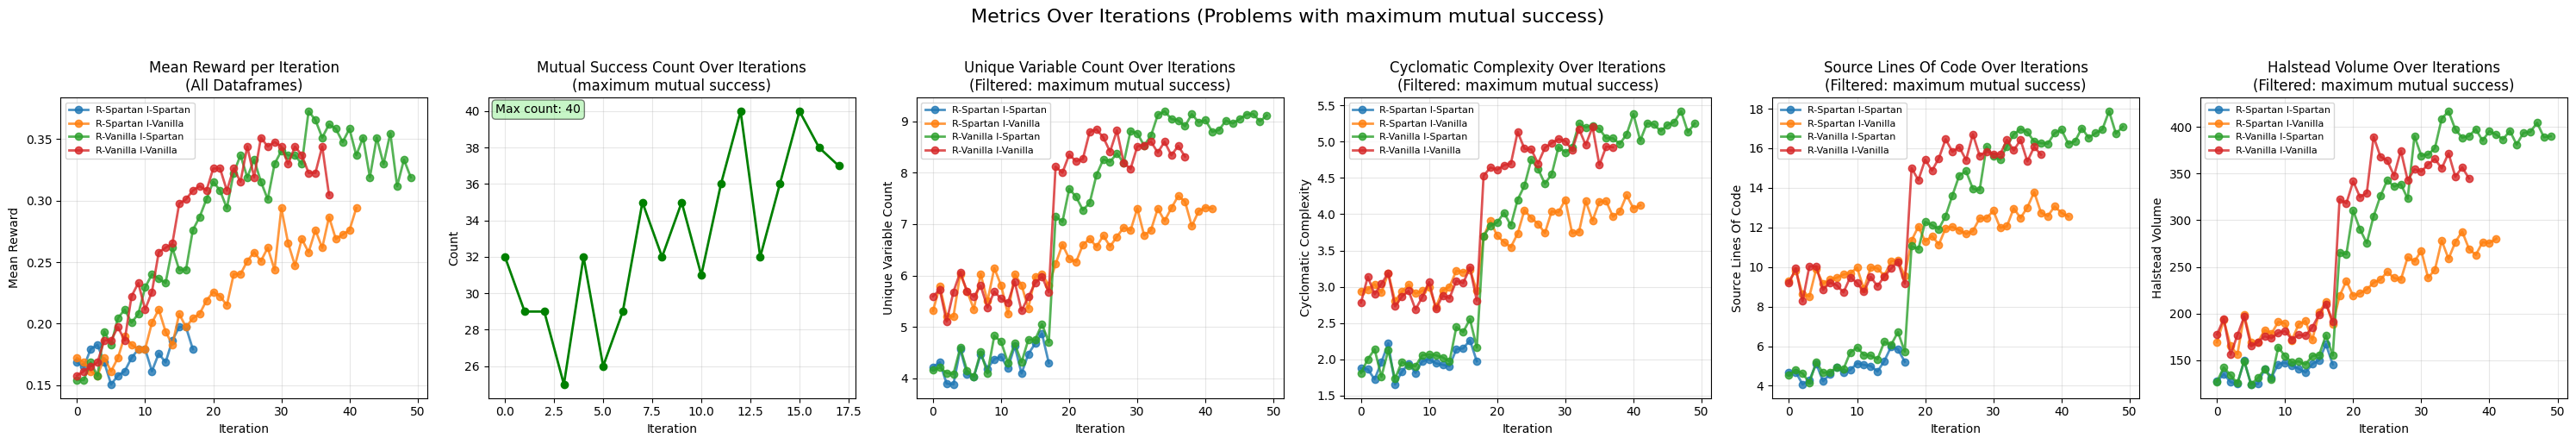

In [20]:
import numpy as np
import matplotlib.pyplot as plt

dataset_size = 279

# Metrics to plot (excluding reward - we'll plot count instead)
metrics = [
    ("unique_variable_count", "Unique Variable Count"),
    ("cyclomatic_complexity", "Cyclomatic Complexity"),
    ("source_lines_of_code", "Source Lines Of Code"),
    ("halstead_volume", "Halstead Volume")
]

# Store results for each iteration - one list per dataframe per metric
# Including r_vanilla_i_vanilla_data for metric plots
dataframes = {
    'r_spartan_i_spartan': r_spartan_i_spartan_data,
    'r_spartan_i_vanilla': r_spartan_i_vanilla_data,
    'r_vanilla_i_spartan': r_vanilla_i_spartan_data,
    'r_vanilla_i_vanilla': r_vanilla_i_vanilla_data
}
dataframe_names = ['r_spartan_i_spartan', 'r_spartan_i_vanilla', 'r_vanilla_i_spartan', 'r_vanilla_i_vanilla']
dataframe_labels = ['R-Spartan I-Spartan', 'R-Spartan I-Vanilla', 'R-Vanilla I-Spartan', 'R-Vanilla I-Vanilla']

# Calculate number of iterations for each dataframe separately
num_iterations_per_df = {
    df_name: len(dataframes[df_name]) // dataset_size
    for df_name in dataframe_names
}
max_iterations = max(num_iterations_per_df.values())

# Store results for each dataframe and metric
iteration_results = {
    df_name: {metric[0]: [] for metric in metrics}
    for df_name in dataframe_names
}
mutual_success_count = []  # Store count of problems with maximum mutual success

# Store mean reward for all 4 dataframes (including r_vanilla_i_vanilla for this plot)
all_dataframes_for_reward = {
    'r_spartan_i_spartan': r_spartan_i_spartan_data,
    'r_spartan_i_vanilla': r_spartan_i_vanilla_data,
    'r_vanilla_i_spartan': r_vanilla_i_spartan_data,
    'r_vanilla_i_vanilla': r_vanilla_i_vanilla_data
}
all_dataframe_names_for_reward = ['r_spartan_i_spartan', 'r_spartan_i_vanilla', 'r_vanilla_i_spartan', 'r_vanilla_i_vanilla']
all_dataframe_labels_for_reward = ['R-Spartan I-Spartan', 'R-Spartan I-Vanilla', 'R-Vanilla I-Spartan', 'R-Vanilla I-Vanilla']
mean_reward = {df_name: [] for df_name in all_dataframe_names_for_reward}  # Store mean reward per iteration

# Process mean reward for each dataframe independently (all iterations)
for df_name in all_dataframe_names_for_reward:
    num_iterations_df = num_iterations_per_df[df_name]
    for iteration in range(num_iterations_df):
        start_idx = iteration * dataset_size
        end_idx = (iteration + 1) * dataset_size
        iter_data = all_dataframes_for_reward[df_name].iloc[start_idx:end_idx].copy()
        mean_reward_value = iter_data['reward'].mean()
        mean_reward[df_name].append(mean_reward_value)

# Process mutual success and metrics for common iterations (up to minimum iterations)
min_iterations = min(num_iterations_per_df.values())
for iteration in range(min_iterations):
    start_idx = iteration * dataset_size
    end_idx = (iteration + 1) * dataset_size
    
    # Extract data for this iteration from all 4 dataframes
    iter_r_spartan_i_spartan = r_spartan_i_spartan_data.iloc[start_idx:end_idx].copy()
    iter_r_spartan_i_vanilla = r_spartan_i_vanilla_data.iloc[start_idx:end_idx].copy()
    iter_r_vanilla_i_spartan = r_vanilla_i_spartan_data.iloc[start_idx:end_idx].copy()
    iter_r_vanilla_i_vanilla = r_vanilla_i_vanilla_data.iloc[start_idx:end_idx].copy()
    
    # Calculate mutual success: find maximum number of dataframes with reward=1
    # For each problem, count how many dataframes have reward=1
    reward_matrix = np.array([
        (iter_r_spartan_i_spartan['reward'] == 1).values,
        (iter_r_spartan_i_vanilla['reward'] == 1).values,
        (iter_r_vanilla_i_spartan['reward'] == 1).values,
        (iter_r_vanilla_i_vanilla['reward'] == 1).values
    ])
    num_successes_per_problem = reward_matrix.sum(axis=0)
    
    # Find the maximum number of successes across all problems
    max_successes = num_successes_per_problem.max()
    
    # Count problems with the maximum number of successes
    if max_successes > 0:
        count = (num_successes_per_problem == max_successes).sum()
    else:
        count = 0
    
    mutual_success_count.append(count)
    
    # Create mask for problems with maximum mutual success
    mask = num_successes_per_problem == max_successes
    
    # Calculate metrics for filtered problems from each dataframe
    filtered_dataframes = {
        'r_spartan_i_spartan': iter_r_spartan_i_spartan[mask],
        'r_spartan_i_vanilla': iter_r_spartan_i_vanilla[mask],
        'r_vanilla_i_spartan': iter_r_vanilla_i_spartan[mask],
        'r_vanilla_i_vanilla': iter_r_vanilla_i_vanilla[mask]
    }
    
    # Store mean values for each metric from each dataframe
    for df_name in dataframe_names:
        filtered_data = filtered_dataframes[df_name]
        for metric_name, _ in metrics:
            if len(filtered_data) > 0:
                metric_values = filtered_data[metric_name].dropna()
                if len(metric_values) > 0:
                    iteration_results[df_name][metric_name].append(metric_values.mean())
                else:
                    iteration_results[df_name][metric_name].append(np.nan)
            else:
                iteration_results[df_name][metric_name].append(np.nan)

# Process metrics for remaining iterations of each dataframe independently
for df_name in dataframe_names:
    num_iterations_df = num_iterations_per_df[df_name]
    # Process iterations beyond the common ones
    for iteration in range(min_iterations, num_iterations_df):
        start_idx = iteration * dataset_size
        end_idx = (iteration + 1) * dataset_size
        iter_data = dataframes[df_name].iloc[start_idx:end_idx].copy()
        
        # For remaining iterations, use all data (no mutual filtering)
        for metric_name, _ in metrics:
            metric_values = iter_data[metric_name].dropna()
            if len(metric_values) > 0:
                iteration_results[df_name][metric_name].append(metric_values.mean())
            else:
                iteration_results[df_name][metric_name].append(np.nan)

# Create subplots (6 subplots: mean reward + mutual success + 4 metrics)
fig, axs = plt.subplots(1, 6, figsize=(30, 5))

# Plot mean reward for each dataframe (first subplot) - all iterations for each dataframe
reward_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # 4 colors for 4 dataframes
for df_idx, df_name in enumerate(all_dataframe_names_for_reward):
    num_iterations_df = num_iterations_per_df[df_name]
    axs[0].plot(range(num_iterations_df), mean_reward[df_name], marker='o', linewidth=2,
                label=all_dataframe_labels_for_reward[df_idx], color=reward_colors[df_idx], alpha=0.8)
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Mean Reward')
axs[0].set_title('Mean Reward per Iteration\n(All Dataframes)')
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='best', fontsize=8)

# Plot count of mutual successes (second subplot)
axs[1].plot(range(min_iterations), mutual_success_count, marker='o', linewidth=2, color='green')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Count')
axs[1].set_title('Mutual Success Count Over Iterations\n(maximum mutual success)')
axs[1].grid(True, alpha=0.3)
if len(mutual_success_count) > 0:
    axs[1].text(0.02, 0.98, f'Max count: {max(mutual_success_count)}', 
                transform=axs[1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Plot each metric (remaining 4 subplots) - one line per dataframe, all iterations
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Different colors for each dataframe (4 colors)
for idx, (metric_name, metric_label) in enumerate(metrics):
    ax_idx = idx + 2  # Start from index 2 (0 is mean reward, 1 is mutual success)
    
    # Plot a line for each dataframe - all iterations
    for df_idx, df_name in enumerate(dataframe_names):
        values = iteration_results[df_name][metric_name]
        num_iterations_df = num_iterations_per_df[df_name]
        axs[ax_idx].plot(range(num_iterations_df), values, marker='o', linewidth=2, 
                        label=dataframe_labels[df_idx], color=colors[df_idx], alpha=0.8)
    
    axs[ax_idx].set_xlabel('Iteration')
    axs[ax_idx].set_ylabel(metric_label)
    axs[ax_idx].set_title(f'{metric_label} Over Iterations\n(Filtered: maximum mutual success)')
    axs[ax_idx].grid(True, alpha=0.3)
    axs[ax_idx].legend(loc='best', fontsize=8)

plt.suptitle('Metrics Over Iterations (Problems with maximum mutual success)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
for i in range(0, r_vanilla_i_vanilla_data.shape[0], dataset_size):
    print(i//dataset_size)
    print(r_vanilla_i_vanilla_data.iloc[i:i+dataset_size].unique_variable_count.mean())

0
5.7555555555555555
1
6.066666666666666
2
5.760869565217392
3
6.297872340425532
4
6.3076923076923075
5
6.1923076923076925
6
6.127272727272727
7
6.288461538461538
8
6.349206349206349
9
6.606060606060606
10
6.174603174603175
11
6.617647058823529
12
7.0125
13
7.271604938271605
14
7.320987654320987
15
7.35632183908046
16
8.115789473684211
17
8.387755102040817
18
8.117647058823529
19
8.0
20
8.351851851851851
21
8.222222222222221
22
8.268518518518519
23
8.792792792792794
24
8.842105263157896
25
8.6875
26
8.409090909090908
27
8.822033898305085
28
8.196428571428571
29
8.071428571428571
30
8.513043478260869
31
8.531531531531531
32
8.605263157894736
33
8.392857142857142
34
8.601769911504425
35
8.339622641509434
36
8.521367521367521
37
8.314285714285715
